using the original cleaned dataset before normalization, relying on 'class weight' attribute to ensure balance in classes

In [114]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt

In [115]:
df = pd.read_csv("diabetes_milestone1_cleaned.csv")

In [116]:
# 1. Split data
X = df.drop(columns=['CLASS'])
y = df['CLASS']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [117]:
# 2. Create Decision Tree with class weights
model = DecisionTreeClassifier(
    class_weight='balanced',   # key line
    max_depth=5,               # control overfitting
    random_state=42
)

In [118]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
X_train['Gender'] = le.fit_transform(X_train['Gender']).astype(float)
X_test['Gender'] = le.transform(X_test['Gender']).astype(float)
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)


In [119]:
X_train

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
482,1.0,54,4.3,63.0,12.1,3.6,5.1,0.9,2.5,0.9,30.0
798,1.0,30,4.6,106.0,8.1,6.8,3.2,0.7,3.6,1.3,23.0
3,0.0,45,2.3,24.0,4.0,2.9,1.0,1.0,1.5,0.4,21.0
59,1.0,40,5.0,63.0,4.0,4.8,2.5,1.1,2.7,1.1,23.0
490,1.0,61,5.9,56.0,10.9,4.6,7.0,0.6,1.3,3.1,30.0
...,...,...,...,...,...,...,...,...,...,...,...
492,0.0,54,7.0,72.0,7.6,4.9,2.8,0.8,3.0,1.2,31.0
33,1.0,46,2.0,54.0,5.4,3.7,1.3,0.8,2.4,0.6,21.0
580,1.0,60,7.5,83.0,7.6,4.6,4.6,0.6,2.7,1.4,33.0
17,0.0,49,13.5,175.0,5.1,0.5,1.9,1.3,2.8,0.8,24.0


In [120]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      0.88      0.93         8
           2       0.99      1.00      1.00       139

    accuracy                           0.99       166
   macro avg       1.00      0.96      0.98       166
weighted avg       0.99      0.99      0.99       166

Confusion Matrix:
 [[ 19   0   0]
 [  0   7   1]
 [  0   0 139]]


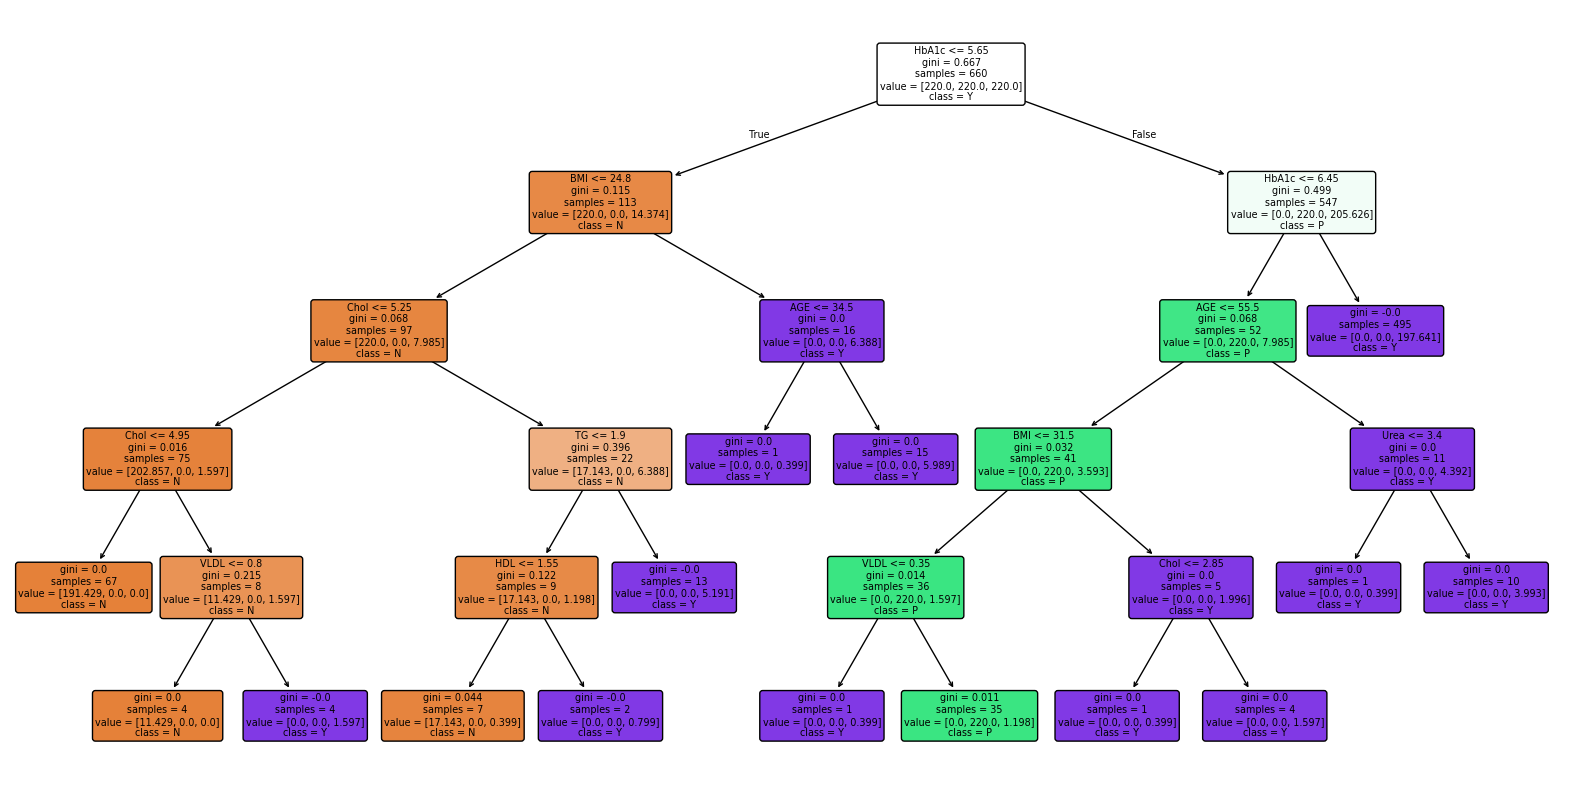

In [121]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['N', 'P', 'Y'], 
    filled=True,
    rounded=True
)

plt.show()

In [122]:
from sklearn.preprocessing import KBinsDiscretizer
features_to_bin = [col for col in X_train.columns if col != 'gender']
kbins = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='kmeans')
X_train_binned = X_train.copy()
X_test_binned = X_test.copy()
X_train_binned[features_to_bin] = kbins.fit_transform(X_train[features_to_bin])
X_test_binned[features_to_bin] = kbins.transform(X_test[features_to_bin])


c:\Users\Hams\Downloads\Data Mining\Assignments\.venv\lib\site-packages\sklearn\base.py:1365: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\Hams\Downloads\Data Mining\Assignments\.venv\lib\site-packages\sklearn\preprocessing\_discretization.py:397: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


In [123]:
# 3. Train
model.fit(X_train_binned, y_train)

# 4. Predict
y_pred_binned = model.predict(X_test_binned)

# 5. Evaluate
print(confusion_matrix(y_test, y_pred_binned))
print(classification_report(y_test, y_pred_binned))

[[  6  13   0]
 [  0   7   1]
 [  0   4 135]]
              precision    recall  f1-score   support

           0       1.00      0.32      0.48        19
           1       0.29      0.88      0.44         8
           2       0.99      0.97      0.98       139

    accuracy                           0.89       166
   macro avg       0.76      0.72      0.63       166
weighted avg       0.96      0.89      0.90       166



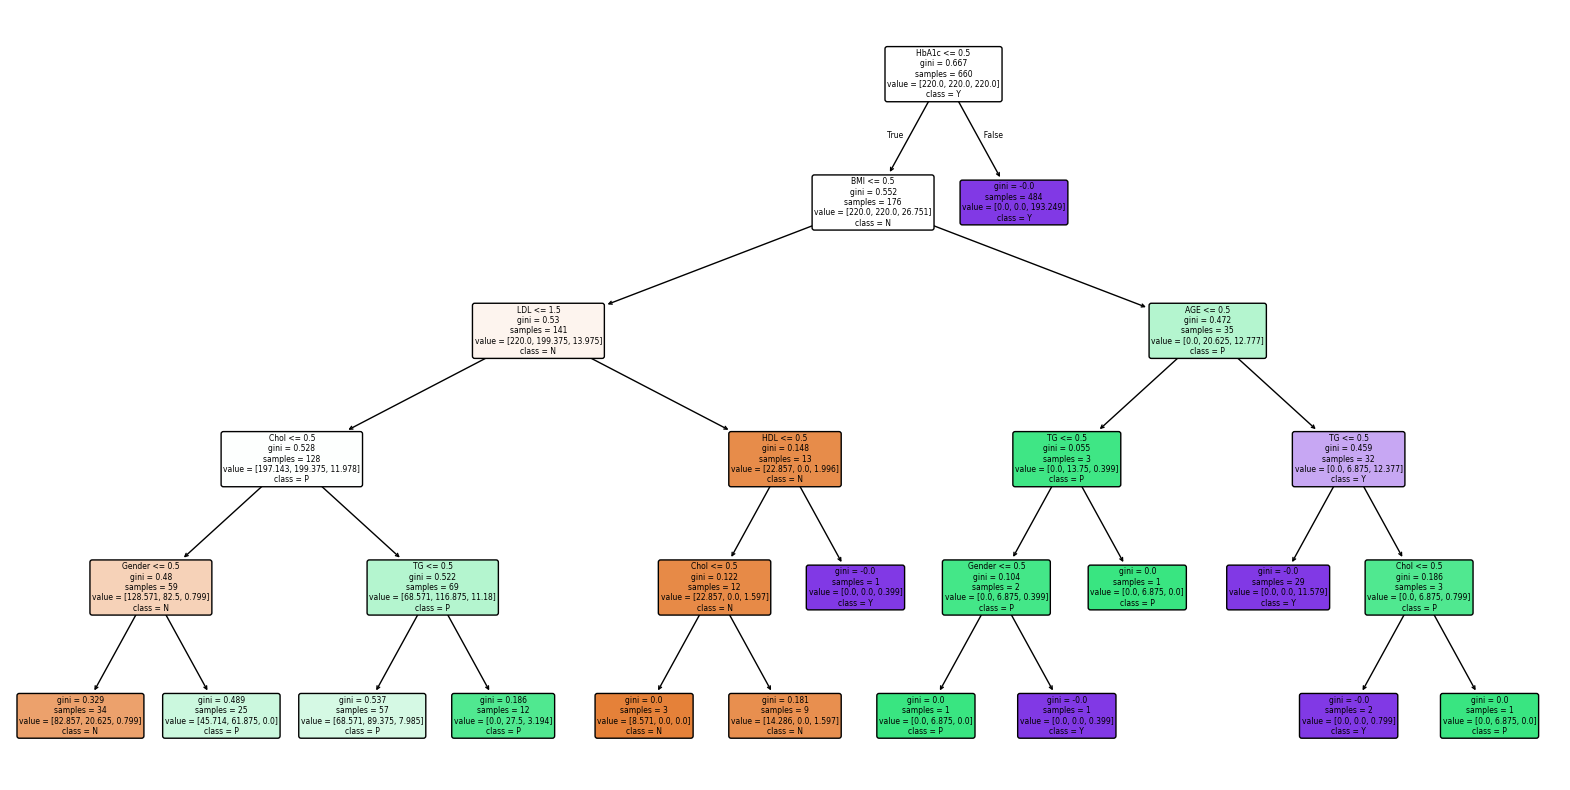

In [124]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['N', 'P', 'Y'],  # change if needed
    filled=True,
    rounded=True
)

plt.show()